# Notebook Integrador — Proyecto 1 CINF104
## Predicción del GRD — Hospital El Pino

Este notebook consolida el **Análisis Exploratorio de Datos (EDA)** y la evaluación comparativa  
de tres modelos de Machine Learning para predecir el código **GRD (Grupo Relacionado de Diagnóstico)**  
de pacientes del Hospital El Pino, usando diagnósticos, procedimientos, edad y sexo como variables predictoras.


## 0. Importaciones y configuración global

In [15]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import (MultiLabelBinarizer, LabelEncoder,
                                   StandardScaler, label_binarize)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted')

IMG_DIR      = 'imagenes'
os.makedirs(IMG_DIR, exist_ok=True)

RANDOM_STATE = 42
DATASET      = 'dataset\dataset_elpino.csv'   # ← ajustar ruta si es necesario
print("Configuración lista ✓")

Configuración lista ✓


## 1. Carga del dataset

In [16]:
df = pd.read_csv(DATASET, sep=';', engine='python')
print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(3)

Shape: 14,561 filas × 68 columnas


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Completitud — porcentaje de valores nulos

In [17]:
missing = df.isnull().mean() * 100
print(f"Columnas con al menos 1 NaN: {(missing > 0).sum()}")
print("\nTop 10 columnas con más nulos:")
print(missing.sort_values(ascending=False).head(10).to_string())

Columnas con al menos 1 NaN: 0

Top 10 columnas con más nulos:
Diag 01 Principal (cod+des)     0.0
Diag 02 Secundario (cod+des)    0.0
Diag 03 Secundario (cod+des)    0.0
Diag 04 Secundario (cod+des)    0.0
Diag 05 Secundario (cod+des)    0.0
Diag 06 Secundario (cod+des)    0.0
Diag 07 Secundario (cod+des)    0.0
Diag 08 Secundario (cod+des)    0.0
Diag 09 Secundario (cod+des)    0.0
Diag 10 Secundario (cod+des)    0.0


### 2.2 Correctitud — rangos y valores únicos

In [18]:
print("=== Edad en años ===")
print(f"  Valores negativos  : {(df['Edad en años'] < 0).sum()}")
print(f"  Valores > 120      : {(df['Edad en años'] > 120).sum()}")
print(df['Edad en años'].describe().to_string())

print("\n=== Sexo (Desc) ===")
print(df['Sexo (Desc)'].value_counts(dropna=False).to_string())

print(f"\n=== GRD únicos: {df['GRD'].nunique()} ===")
print(df['GRD'].value_counts().head(5).to_string())

=== Edad en años ===
  Valores negativos  : 0
  Valores > 120      : 1
count    14561.000000
mean        39.426550
std         24.681545
min          0.000000
25%         23.000000
50%         36.000000
75%         60.000000
max        121.000000

=== Sexo (Desc) ===
Sexo (Desc)
Mujer     9617
Hombre    4944

=== GRD únicos: 526 ===
GRD
146101 - PH CESÁREA                                                                       813
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO    639
146131 - PH PARTO VAGINAL                                                                 538
158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR                       389
134161 - MH TRASTORNOS DEL ANTEPARTO                                                      325


### 2.3 Histograma — Distribución de Edad

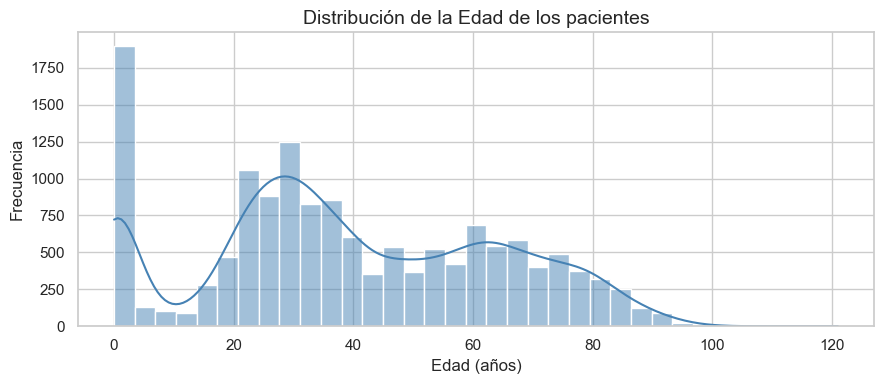

In [19]:
plt.figure(figsize=(9, 4))
sns.histplot(df['Edad en años'], bins=35, kde=True, color='steelblue')
plt.title('Distribución de la Edad de los pacientes', fontsize=14)
plt.xlabel('Edad (años)'); plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'distribucion_edad.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Outliers — Boxplot de Edad

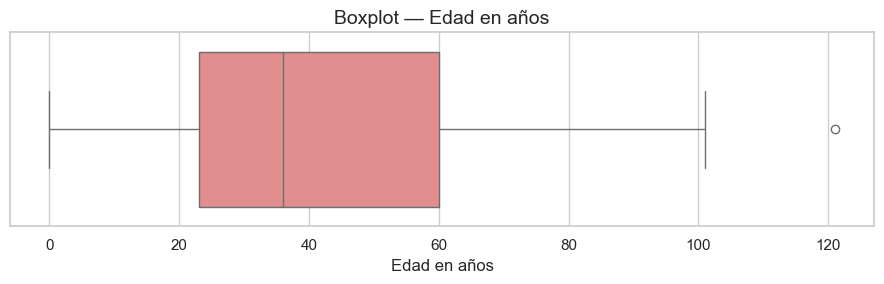

In [20]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=df['Edad en años'], color='lightcoral')
plt.title('Boxplot — Edad en años', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'boxplot_edad.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Distribución por Sexo

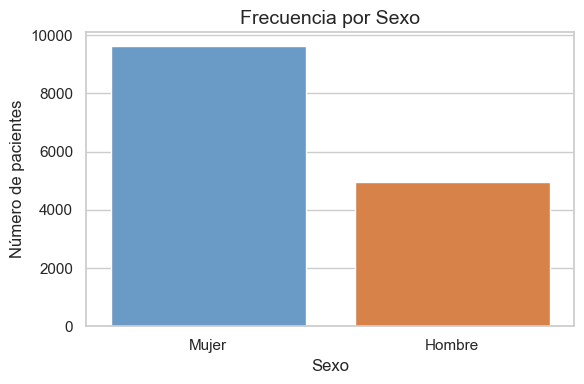

In [21]:
plt.figure(figsize=(6, 4))
vc = df['Sexo (Desc)'].value_counts().reset_index()
vc.columns = ['Sexo', 'Count']
sns.barplot(data=vc, x='Sexo', y='Count', hue='Sexo',
            palette=['#5B9BD5', '#ED7D31'], legend=False)
plt.title('Frecuencia por Sexo', fontsize=14)
plt.xlabel('Sexo'); plt.ylabel('Número de pacientes')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'distribucion_sexo.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Top 10 GRD más frecuentes

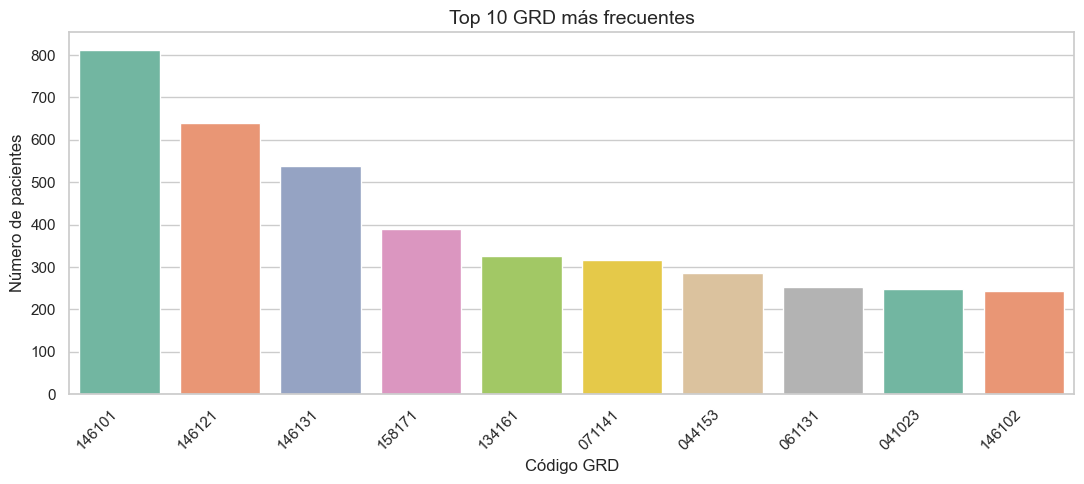

In [22]:
top_grd = df['GRD'].str.split(' - ').str[0].value_counts().nlargest(10)
top_df  = top_grd.reset_index(); top_df.columns = ['GRD', 'Count']

plt.figure(figsize=(11, 5))
sns.barplot(data=top_df, x='GRD', y='Count', hue='GRD', palette='Set2', legend=False)
plt.title('Top 10 GRD más frecuentes', fontsize=14)
plt.xlabel('Código GRD'); plt.ylabel('Número de pacientes')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'top10_grd.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocesamiento


In [23]:
# --- 3.1 Limpiar GRD y Sexo ---
df['GRD']  = df['GRD'].str.split(' - ').str[0]
df['Sexo'] = df['Sexo (Desc)'].map({'Hombre': 0, 'Mujer': 1}).fillna(0)

# --- 3.2 Diagnósticos y procedimientos ---
diags = [c for c in df.columns if 'Diag'   in c]
procs = [c for c in df.columns if 'Proced' in c]

for col in diags + procs:
    df[col] = df[col].astype(str).str.split(' - ').str[0]

df['diag_list'] = df[diags].values.tolist()
df['proc_list'] = df[procs].values.tolist()

# --- 3.3 MultiLabelBinarizer (sparse) ---
mlb_diag = MultiLabelBinarizer(sparse_output=True)
mlb_proc = MultiLabelBinarizer(sparse_output=True)
X_diag   = mlb_diag.fit_transform(df['diag_list'])
X_proc   = mlb_proc.fit_transform(df['proc_list'])

# --- 3.4 Escalar Edad ---
scaler = StandardScaler()
edad_scaled = csr_matrix(scaler.fit_transform(df[['Edad en años']].fillna(0)))

# --- 3.5 Sexo como sparse ---
sexo_sp = csr_matrix(df[['Sexo']].values)

# --- 3.6 Matriz de features final ---
X = hstack([X_diag, X_proc, edad_scaled, sexo_sp], format='csr')

# --- 3.7 Target variables ---
rare = df['GRD'].value_counts()
rare = rare[rare < 5].index
df['GRD_grouped'] = df['GRD'].where(~df['GRD'].isin(rare), other='Other')

y_grouped = df['GRD_grouped']   # para LR y MLP
y_full    = df['GRD']           # para RF (todas las clases)

print(f"X shape            : {X.shape}")
print(f"Clases agrupadas   : {y_grouped.nunique()}")
print(f"Clases completas   : {y_full.nunique()}")

# --- 3.8 Partición estratificada ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_grouped, stratify=y_grouped, test_size=0.2, random_state=RANDOM_STATE)

X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X, y_full, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train grouped      : {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train RF (full)    : {X_tr_rf.shape}  |  Test: {X_te_rf.shape}")

X shape            : (14561, 4555)
Clases agrupadas   : 328
Clases completas   : 526
Train grouped      : (11648, 4555)  |  Test: (2913, 4555)
Train RF (full)    : (11648, 4555)  |  Test: (2913, 4555)


## 4. Modelo 1 — Regresión Logística

- Solver `lbfgs`, regularización L2 (`C=1.0`), `max_iter=1000`.
- Se entrena sobre las clases agrupadas (`GRD_grouped`).

In [24]:
t0 = time.time()
modelo_lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    C=1.0,
    random_state=RANDOM_STATE
)
modelo_lr.fit(X_train, y_train)
print(f"Entrenado en {time.time() - t0:.1f}s")

y_pred_lr = modelo_lr.predict(X_test)

acc_lr  = accuracy_score(y_test, y_pred_lr)
f1m_lr  = f1_score(y_test, y_pred_lr, average='macro',    zero_division=0)
f1w_lr  = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)
prec_lr = precision_score(y_test, y_pred_lr, average='macro', zero_division=0)
rec_lr  = recall_score(y_test,  y_pred_lr, average='macro', zero_division=0)

print(f"Accuracy       : {acc_lr:.4f}")
print(f"F1 Macro       : {f1m_lr:.4f}")
print(f"F1 Weighted    : {f1w_lr:.4f}")
print(f"Precision Macro: {prec_lr:.4f}")
print(f"Recall Macro   : {rec_lr:.4f}")

Entrenado en 43.7s
Accuracy       : 0.6423
F1 Macro       : 0.3082
F1 Weighted    : 0.6118
Precision Macro: 0.3322
Recall Macro   : 0.3079


### 4.1 Curva ROC micro-promediada — Regresión Logística

AUC micro (LR) : 0.9915


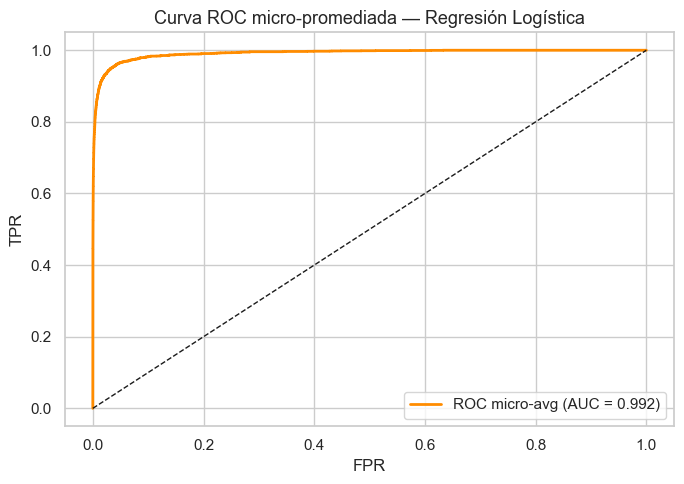

In [25]:
classes_lr   = modelo_lr.classes_
y_test_bin_lr = label_binarize(y_test, classes=classes_lr)
y_score_lr   = modelo_lr.predict_proba(X_test)

fpr_lr, tpr_lr, _ = roc_curve(y_test_bin_lr.ravel(), y_score_lr.ravel())
auc_lr = auc(fpr_lr, tpr_lr)
print(f"AUC micro (LR) : {auc_lr:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, lw=2, color='darkorange',
         label=f'ROC micro-avg (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC micro-promediada — Regresión Logística', fontsize=13)
plt.legend(loc='lower right'); plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'roc_lr.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Matriz de confusión — Regresión Logística

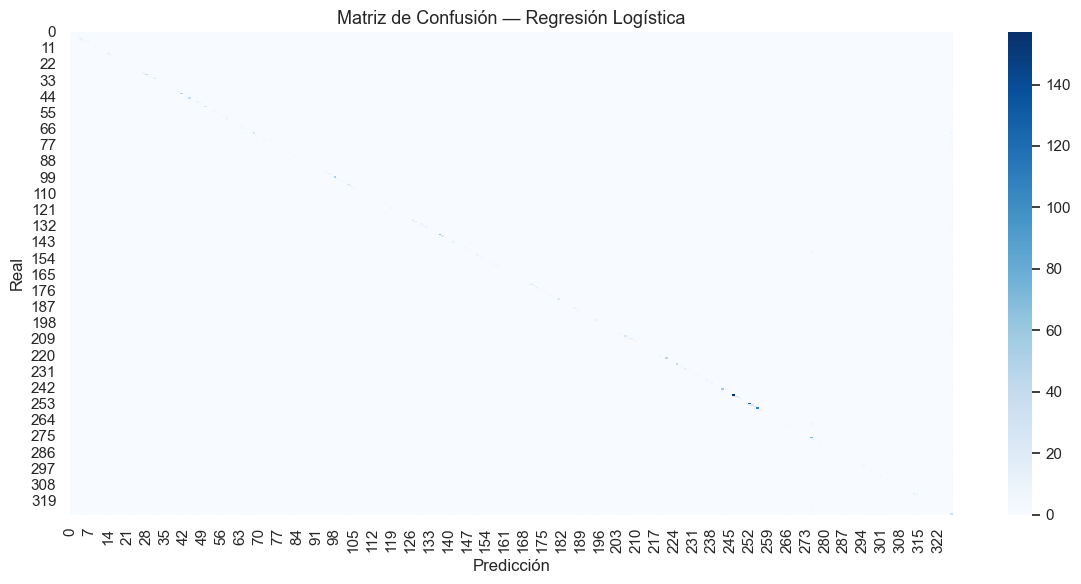

In [26]:
plt.figure(figsize=(12, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=False, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión — Regresión Logística', fontsize=13)
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'matriz_confusion_lr.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Modelo 2 — Random Forest

Se entrena sobre **todas las clases originales** (sin agrupación) para aprovechar la robustez  
del ensemble ante alta cardinalidad. Se comparan dos configuraciones para diagnosticar sobreajuste:

| Config       | n_estimators | max_depth |
|--------------|:------------:|:---------:|
| Profunda     | 50           | 15        |
| Regularizada | 25           | 10        |

In [29]:
# ── Configuración profunda (referencia de sobreajuste) ──────────────────────
rf_deep = RandomForestClassifier(n_estimators=50, max_depth=15,
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_deep.fit(X_tr_rf, y_tr_rf)
acc_d_tr = accuracy_score(y_tr_rf, rf_deep.predict(X_tr_rf))
acc_d_te = accuracy_score(y_te_rf, rf_deep.predict(X_te_rf))
f1_d_tr  = f1_score(y_tr_rf, rf_deep.predict(X_tr_rf), average='macro', zero_division=0)
f1_d_te  = f1_score(y_te_rf, rf_deep.predict(X_te_rf), average='macro', zero_division=0)
print(f"RF profundo  | train acc={acc_d_tr:.4f}  test acc={acc_d_te:.4f}")
print(f"             | train F1 ={f1_d_tr:.4f}  test F1 ={f1_d_te:.4f}")

# ── Configuración regularizada (modelo final RF) ─────────────────────────────
rf_reg = RandomForestClassifier(n_estimators=25, max_depth=10,
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_tr_rf, y_tr_rf)
y_pred_rf = rf_reg.predict(X_te_rf)

acc_rf  = accuracy_score(y_te_rf, y_pred_rf)
f1m_rf  = f1_score(y_te_rf, y_pred_rf, average='macro',    zero_division=0)
f1w_rf  = f1_score(y_te_rf, y_pred_rf, average='weighted', zero_division=0)
prec_rf = precision_score(y_te_rf, y_pred_rf, average='macro', zero_division=0)
rec_rf  = recall_score(y_te_rf,  y_pred_rf, average='macro', zero_division=0)

print(f"\nRF regular.  | acc={acc_rf:.4f}  F1-mac={f1m_rf:.4f}  F1-wtd={f1w_rf:.4f}")
print(f"             | Precision={prec_rf:.4f}  Recall={rec_rf:.4f}")

RF profundo  | train acc=0.6288  test acc=0.4181
             | train F1 =0.4037  test F1 =0.0824

RF regular.  | acc=0.3591  F1-mac=0.0642  F1-wtd=0.2640
             | Precision=0.0996  Recall=0.0714


### 5.1 AUC — Random Forest

AUC micro (RF) : 0.9379


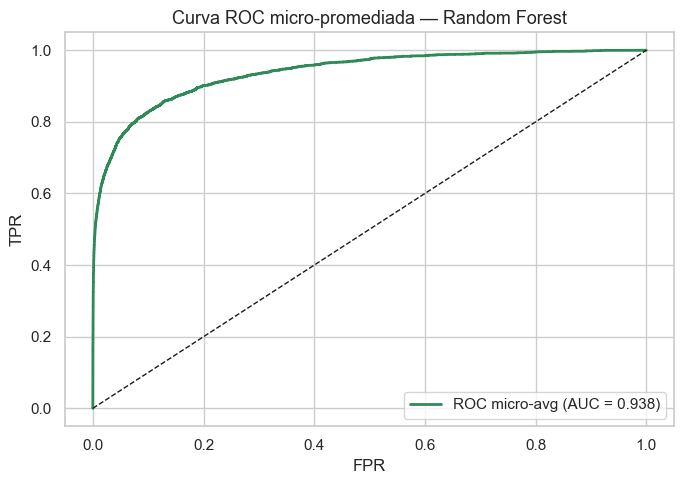

In [30]:
y_score_rf      = rf_reg.predict_proba(X_te_rf)
classes_rf      = rf_reg.classes_
y_test_bin_rf   = label_binarize(y_te_rf, classes=classes_rf)

# micro-average AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin_rf.ravel(), y_score_rf.ravel())
auc_rf = auc(fpr_rf, tpr_rf)
print(f"AUC micro (RF) : {auc_rf:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, lw=2, color='seagreen',
         label=f'ROC micro-avg (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC micro-promediada — Random Forest', fontsize=13)
plt.legend(loc='lower right'); plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'roc_rf.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Importancia de features — Top 20

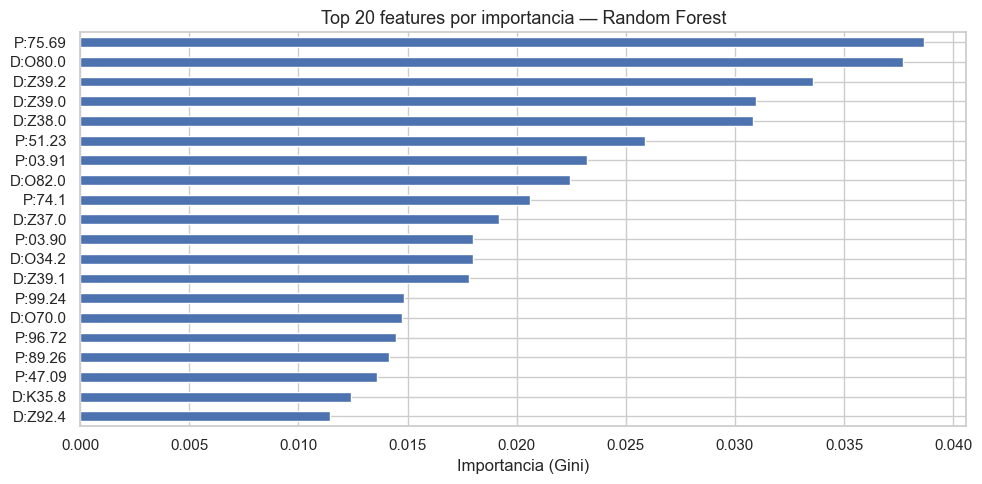

In [31]:
importances = rf_reg.feature_importances_
n_diag = X_diag.shape[1]; n_proc = X_proc.shape[1]
names = (
    [f'D:{c}' for c in mlb_diag.classes_] +
    [f'P:{c}' for c in mlb_proc.classes_] +
    ['Edad (scaled)', 'Sexo']
)
feat_df = pd.Series(importances, index=names).nlargest(20)

plt.figure(figsize=(10, 5))
feat_df[::-1].plot(kind='barh', color='#4C72B0')
plt.title('Top 20 features por importancia — Random Forest', fontsize=13)
plt.xlabel('Importancia (Gini)'); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'feature_importance_rf.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Matriz de confusión — Random Forest

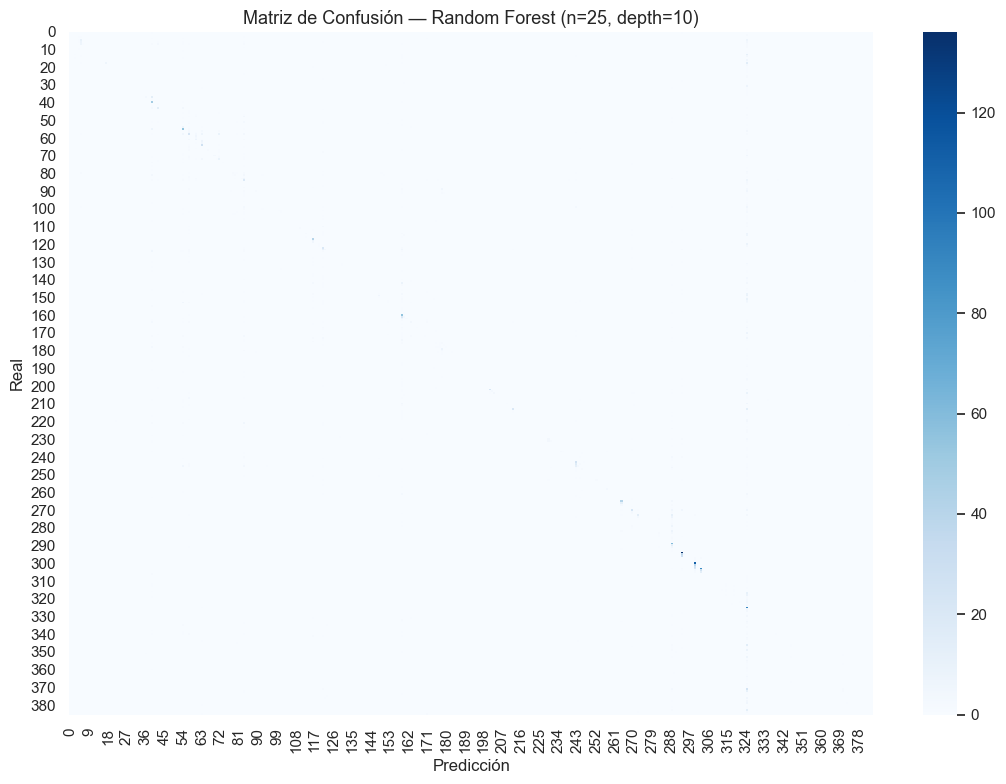

In [32]:
plt.figure(figsize=(11, 8))
sns.heatmap(confusion_matrix(y_te_rf, y_pred_rf),
            annot=False, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión — Random Forest (n=25, depth=10)', fontsize=13)
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'matriz_confusion_rf.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Modelo 3 — Red Neuronal MLP (`sklearn.neural_network.MLPClassifier`)

Arquitectura basada en la búsqueda de hiperparámetros con Keras Tuner:

| Capa   | Neuronas | Activación |
|--------|:--------:|:----------:|
| Input  | —        | —          |
| Dense  | 160      | ReLU       |
| Dense  | 192      | ReLU       |
| Dense  | 160      | ReLU       |
| Output | n_clases | Softmax    |

**Hiperparámetros:** regularización L2 (`alpha=0.001`), Adam (`lr=5e-4`),  
`batch_size=64`, `early_stopping=True`, `validation_fraction=0.2`, paciencia=10.

> Se usa `sklearn.neural_network.MLPClassifier` (sin TensorFlow) para máxima portabilidad.

In [33]:
le_mlp = LabelEncoder()
y_train_enc = le_mlp.fit_transform(y_train)
y_test_enc  = le_mlp.transform(y_test)
num_classes = len(le_mlp.classes_)

# Convertir sparse → denso (requerimiento de MLPClassifier)
X_train_d = X_train.toarray()
X_test_d  = X_test.toarray()

t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(160, 192, 160),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0005,
    alpha=0.001,
    batch_size=64,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
    verbose=False,
)
mlp.fit(X_train_d, y_train_enc)
print(f"Entrenado en {time.time() - t0:.1f}s  |  épocas efectivas: {mlp.n_iter_}")

Entrenado en 196.9s  |  épocas efectivas: 24


In [34]:
y_pred_enc = mlp.predict(X_test_d)
y_pred_mlp = le_mlp.inverse_transform(y_pred_enc)

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
f1m_mlp  = f1_score(y_test, y_pred_mlp, average='macro',    zero_division=0)
f1w_mlp  = f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
prec_mlp = precision_score(y_test, y_pred_mlp, average='macro', zero_division=0)
rec_mlp  = recall_score(y_test,  y_pred_mlp, average='macro', zero_division=0)

# AUC (macro OvR)
y_score_mlp   = mlp.predict_proba(X_test_d)
y_test_binar  = label_binarize(y_test_enc, classes=range(num_classes))
auc_mlp_macro = roc_auc_score(y_test_binar, y_score_mlp, average='macro',    multi_class='ovr')
auc_mlp_wtd   = roc_auc_score(y_test_binar, y_score_mlp, average='weighted', multi_class='ovr')

print(f"Accuracy       : {acc_mlp:.4f}")
print(f"F1 Macro       : {f1m_mlp:.4f}")
print(f"F1 Weighted    : {f1w_mlp:.4f}")
print(f"Precision Macro: {prec_mlp:.4f}")
print(f"Recall Macro   : {rec_mlp:.4f}")
print(f"AUC Macro      : {auc_mlp_macro:.4f}")
print(f"AUC Weighted   : {auc_mlp_wtd:.4f}")

Accuracy       : 0.6722
F1 Macro       : 0.3786
F1 Weighted    : 0.6586
Precision Macro: 0.4019
Recall Macro   : 0.3927
AUC Macro      : 0.9760
AUC Weighted   : 0.9858


### 6.1 Curvas de aprendizaje — MLP

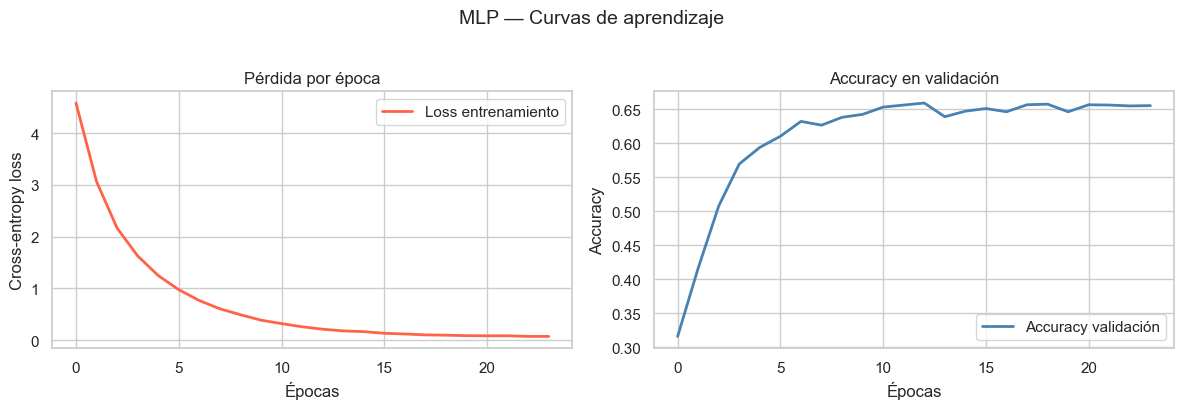

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp.loss_curve_, color='tomato', lw=2, label='Loss entrenamiento')
axes[0].set_title('Pérdida por época'); axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Cross-entropy loss'); axes[0].legend()

axes[1].plot(mlp.validation_scores_, color='steelblue', lw=2, label='Accuracy validación')
axes[1].set_title('Accuracy en validación'); axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.suptitle('MLP — Curvas de aprendizaje', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'mlp_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Curvas ROC — Top 10 GRD (MLP)

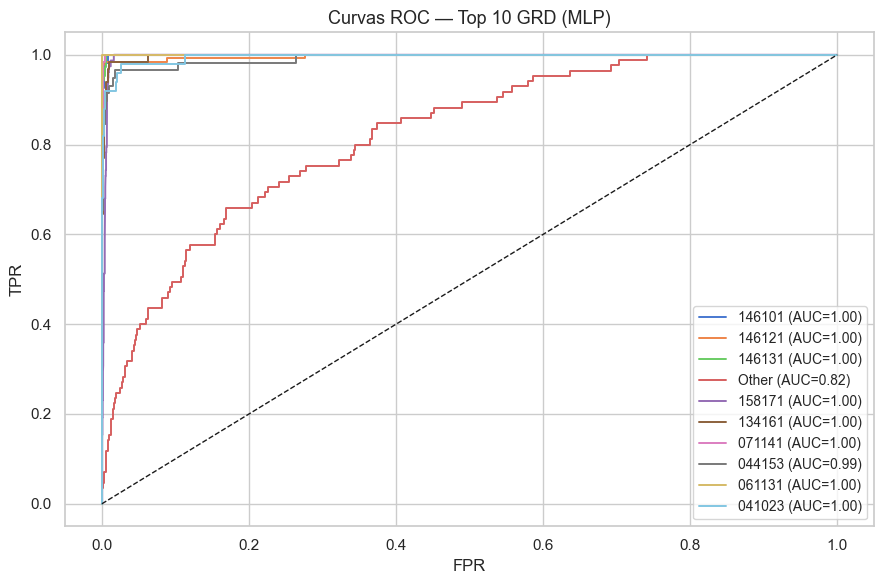

In [36]:
fpr_d, tpr_d, auc_d = {}, {}, {}
for i in range(num_classes):
    fpr_d[i], tpr_d[i], _ = roc_curve(y_test_binar[:, i], y_score_mlp[:, i])
    auc_d[i] = auc(fpr_d[i], tpr_d[i])

top10_idx = pd.Series(y_test_enc).value_counts().head(10).index.tolist()
plt.figure(figsize=(9, 6))
for idx in top10_idx:
    plt.plot(fpr_d[idx], tpr_d[idx], lw=1.4,
             label=f'{le_mlp.classes_[idx]} (AUC={auc_d[idx]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curvas ROC — Top 10 GRD (MLP)', fontsize=13)
plt.legend(loc='lower right', fontsize='small')
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'roc_mlp.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Matriz de confusión — MLP

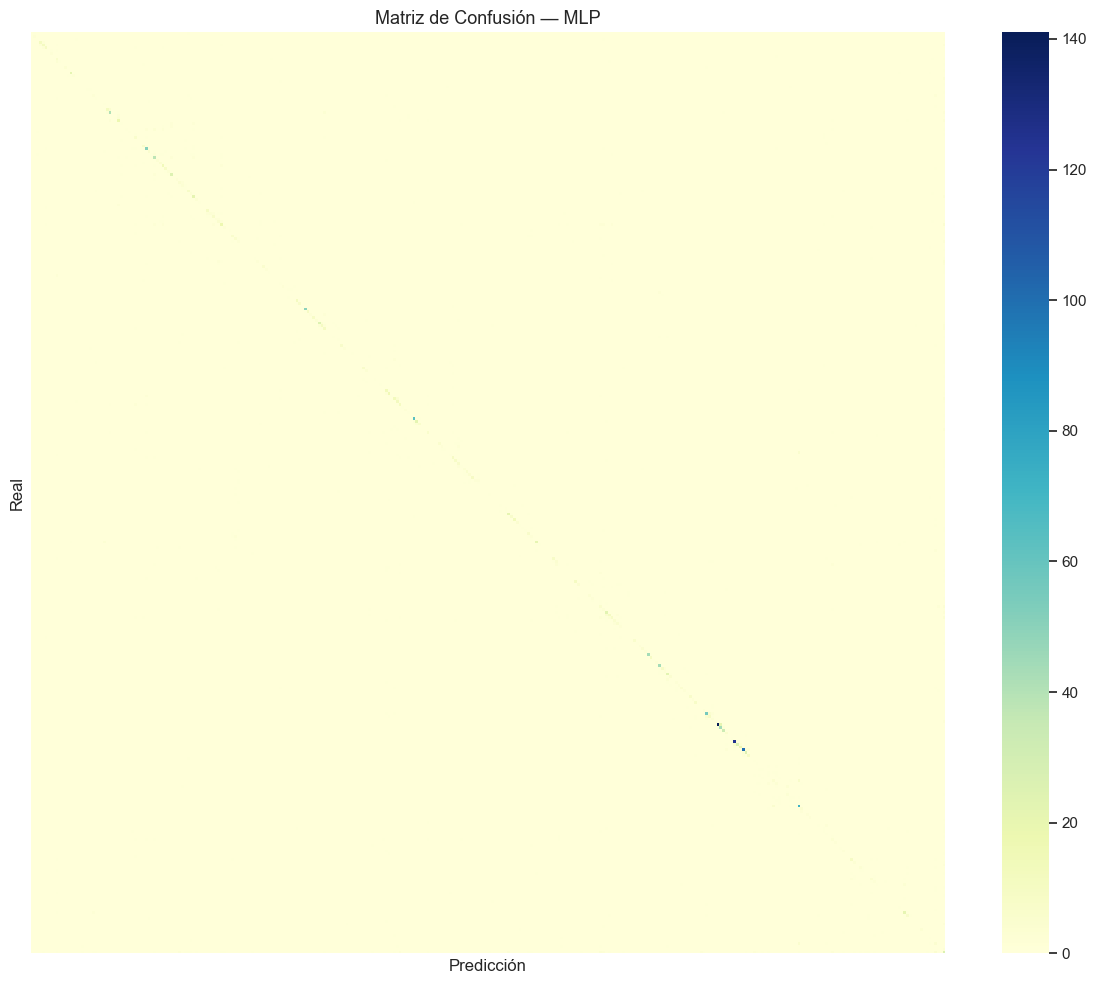

In [37]:
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test_enc, y_pred_enc),
            annot=False, cmap='YlGnBu',
            xticklabels=False, yticklabels=False)
plt.title('Matriz de Confusión — MLP', fontsize=13)
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'matriz_confusion_mlp.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparativa final de los tres modelos

In [38]:
comp = pd.DataFrame({
    'Modelo'         : ['Regresión Logística', 'Random Forest (reg.)', 'MLP (sklearn)'],
    'Accuracy'       : [acc_lr,       acc_rf,       acc_mlp],
    'F1 Macro'       : [f1m_lr,       f1m_rf,       f1m_mlp],
    'F1 Weighted'    : [f1w_lr,       f1w_rf,       f1w_mlp],
    'Precision Macro': [prec_lr,      prec_rf,      prec_mlp],
    'Recall Macro'   : [rec_lr,       rec_rf,       rec_mlp],
    'AUC micro/macro': [auc_lr,       auc_rf,       auc_mlp_macro],
})

print("=" * 85)
print(comp.round(4).to_string(index=False))
print("=" * 85)
comp

              Modelo  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro  AUC micro/macro
 Regresión Logística    0.6423    0.3082       0.6118           0.3322        0.3079           0.9915
Random Forest (reg.)    0.3591    0.0642       0.2640           0.0996        0.0714           0.9379
       MLP (sklearn)    0.6722    0.3786       0.6586           0.4019        0.3927           0.9760


,Modelo,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,AUC micro/macro
0,Regresión Logística,0.642293,0.308213,0.611823,0.332163,0.307949,0.991528
1,Random Forest (reg.),0.359080,0.064164,0.263955,0.099593,0.071353,0.937939
2,MLP (sklearn),0.672159,0.378588,0.658615,0.401918,0.392721,0.976010


### 7.1 Gráfico de barras comparativo

In [ ]:
metrics   = ['Accuracy', 'F1 Macro', 'F1 Weighted']
modelos   = comp['Modelo'].tolist()
x         = np.arange(len(modelos))
width     = 0.22
colors    = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(11, 5))
for j, (met, col) in enumerate(zip(metrics, colors)):
    ax.bar(x + (j - 1) * width, comp[met], width, label=met, color=col, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylim(0, 1.05); ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparativa de modelos en el set de test', fontsize=14)
ax.legend(fontsize=11); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'comparativa_modelos.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Radar chart de métricas

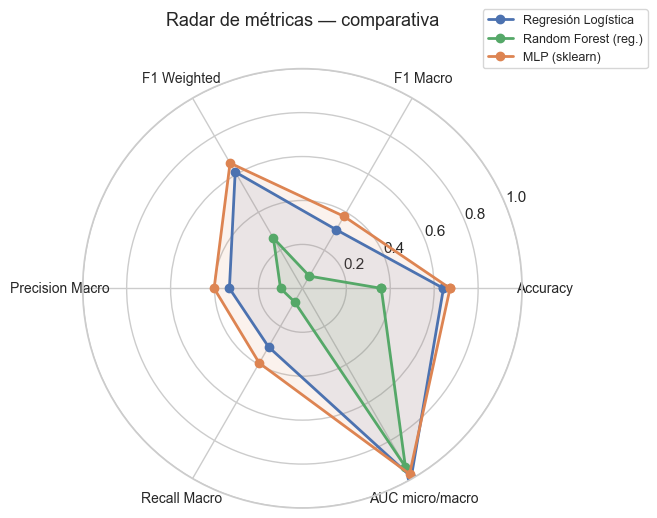

In [40]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

cats   = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision Macro', 'Recall Macro', 'AUC micro/macro']
N      = len(cats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
palette = ['#4C72B0', '#55A868', '#DD8452']

for i, (_, row) in enumerate(comp.iterrows()):
    vals = [row[c] for c in cats] + [row[cats[0]]]
    ax.plot(angles, vals, 'o-', lw=2, color=palette[i], label=row['Modelo'])
    ax.fill(angles, vals, alpha=0.10, color=palette[i])

ax.set_thetagrids(np.degrees(angles[:-1]), cats, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Radar de métricas — comparativa', fontsize=13, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'radar_modelos.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Ejemplo de predicción para un paciente nuevo

Se construye manualmente un vector de entrada y se obtiene la predicción GRD de los tres modelos.

In [45]:
# Datos del paciente de ejemplo
diags_in = ['U07.1', 'R06.0', 'J12.8']
procs_in = ['96.72', '96.04']
edad_in  = np.array([[64.0]])
sexo_in  = np.array([[0]])        # 0 = Hombre

# Codificar igual que el preprocesamiento
diag_vec  = mlb_diag.transform([diags_in])
proc_vec  = mlb_proc.transform([procs_in])
edad_sc   = csr_matrix(scaler.transform(edad_in))
sexo_sp   = csr_matrix(sexo_in)
X_in      = hstack([diag_vec, proc_vec, edad_sc, sexo_sp], format='csr')

pred_lr  = modelo_lr.predict(X_in)[0]
pred_rf  = rf_reg.predict(X_in)[0]
pred_mlp = le_mlp.inverse_transform(mlp.predict(X_in.toarray()))[0]

print("=" * 45)
print(f"  Regresión Logística : {pred_lr}")
print(f"  Random Forest       : {pred_rf}")
print(f"  MLP                 : {pred_mlp}")
print("=" * 45)

  Regresión Logística : 041023
  Random Forest       : 041023
  MLP                 : 041023
